In [ ]:
import pandas as pd


In [ ]:
df=pd.read_csv("creditcard_fraud.csv")
df.head(n=5)

,cardholder_name,card_number,merchant_name,merchant_category,amount,hour,distance_from_home,is_online,is_foreign,velocity_last_hour,is_fraud
0,Allison Hill,4961023726432058,"Merchant: Calhoun, Davis and Richmond",grocery,189.90,6,0.63,1,1,1,0
1,Noah Rhodes,4997245971557937,Merchant: Powell and Sons,online_shopping,14.50,15,1.12,0,0,2,0
2,Angie Henderson,4770115491773269,Merchant: Cox-Mejia,dining,23.46,16,27.38,1,0,0,0
3,Daniel Wagner,4968568888610852,"Merchant: Ortiz, Snow and Garner",grocery,30.00,6,5.75,1,0,0,0
4,Cristian Santos,4358679433644706,Merchant: Barker PLC,grocery,63.56,17,0.42,1,0,1,0


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cardholder_name     10000 non-null  object 
 1   card_number         10000 non-null  int64  
 2   merchant_name       10000 non-null  object 
 3   merchant_category   10000 non-null  object 
 4   amount              10000 non-null  float64
 5   hour                10000 non-null  int64  
 6   distance_from_home  10000 non-null  float64
 7   is_online           10000 non-null  int64  
 8   is_foreign          10000 non-null  int64  
 9   velocity_last_hour  10000 non-null  int64  
 10  is_fraud            10000 non-null  int64  
dtypes: float64(2), int64(6), object(3)
memory usage: 859.5+ KB


In [ ]:
df.describe()

,card_number,amount,hour,distance_from_home,is_online,is_foreign,velocity_last_hour,is_fraud
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.498889e+15,44.761668,11.855400,13.365690,0.306900,0.045500,1.164300,0.017000
std,2.881582e+14,94.051537,4.816244,20.723432,0.461231,0.208408,1.153793,0.129277
min,4.000005e+15,2.000000,0.000000,0.100000,0.000000,0.000000,0.000000,0.000000
25%,4.251080e+15,18.947500,8.000000,3.500000,0.000000,0.000000,0.000000,0.000000
50%,4.496725e+15,30.340000,12.000000,8.440000,0.000000,0.000000,1.000000,0.000000
75%,4.747351e+15,49.020000,15.000000,17.020000,1.000000,0.000000,2.000000,0.000000
max,4.999845e+15,4530.530000,23.000000,450.000000,1.000000,1.000000,10.000000,1.000000


In [ ]:
trasc=df['is_fraud'].value_counts()
print(trasc)

is_fraud
0    9830
1     170
Name: count, dtype: int64


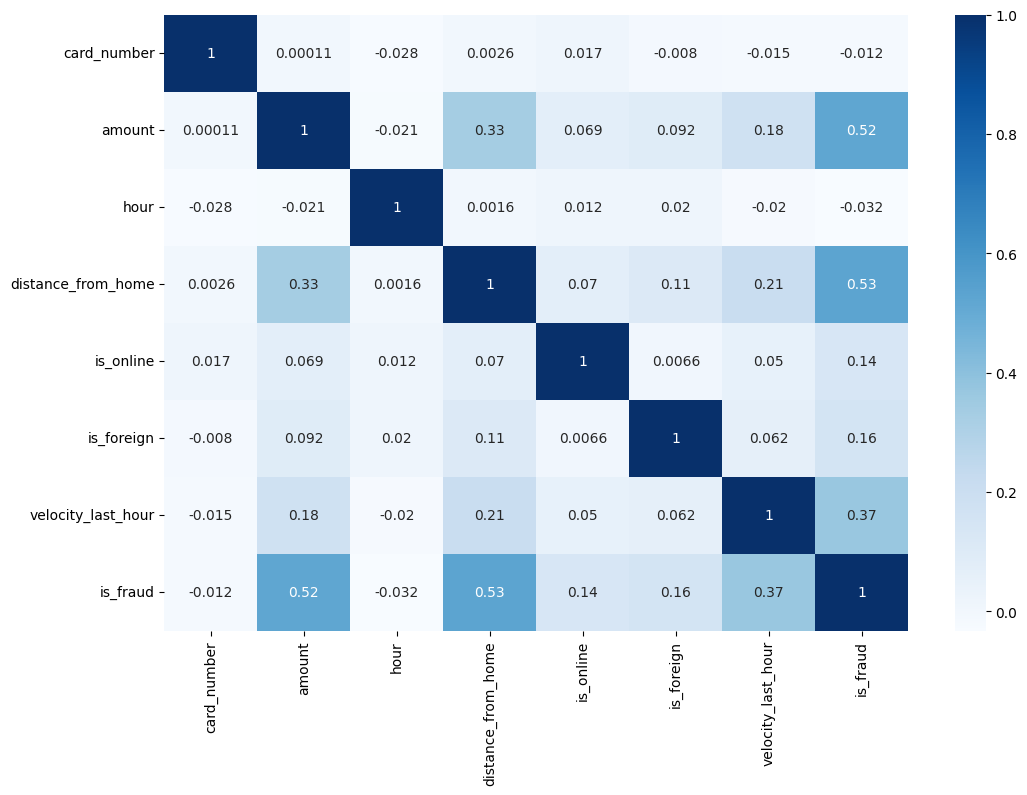

In [ ]:
from matplotlib import figure
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
cm=df.corr(numeric_only=True)
sns.heatmap(cm,annot=True,cmap='Blues')
plt.show()

In [ ]:
df_ml=df.drop(columns=['cardholder_name','card_number','merchant_name'])
df_ml

,merchant_category,amount,hour,distance_from_home,is_online,is_foreign,velocity_last_hour,is_fraud
0,grocery,189.90,6,0.63,1,1,1,0
1,online_shopping,14.50,15,1.12,0,0,2,0
2,dining,23.46,16,27.38,1,0,0,0
3,grocery,30.00,6,5.75,1,0,0,0
4,grocery,63.56,17,0.42,1,0,1,0
...,...,...,...,...,...,...,...,...
9995,grocery,20.05,15,1.69,1,0,1,0
9996,dining,29.11,17,18.35,0,0,1,0
9997,dining,18.36,13,39.22,0,0,2,0
9998,dining,34.54,13,25.69,0,0,1,0


In [ ]:
df_ml=df.drop(columns=['cardholder_name','card_number','merchant_name'])
df_ml=pd.get_dummies(df_ml, columns=['merchant_category'],drop_first=True)
df_ml

,amount,hour,distance_from_home,is_online,is_foreign,velocity_last_hour,is_fraud,merchant_category_electronics,merchant_category_gas_station,merchant_category_grocery,merchant_category_online_shopping,merchant_category_travel
0,189.90,6,0.63,1,1,1,0,False,False,True,False,False
1,14.50,15,1.12,0,0,2,0,False,False,False,True,False
2,23.46,16,27.38,1,0,0,0,False,False,False,False,False
3,30.00,6,5.75,1,0,0,0,False,False,True,False,False
4,63.56,17,0.42,1,0,1,0,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,20.05,15,1.69,1,0,1,0,False,False,True,False,False
9996,29.11,17,18.35,0,0,1,0,False,False,False,False,False
9997,18.36,13,39.22,0,0,2,0,False,False,False,False,False
9998,34.54,13,25.69,0,0,1,0,False,False,False,False,False


In [ ]:
x=df_ml.drop(columns=['is_fraud'])
y=df_ml['is_fraud']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
#

In [ ]:
from sklearn.ensemble import RandomForestClassifier


In [ ]:
model=RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')
model.fit(x_train,y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
y_predicted=model.predict(x_test)

In [ ]:
from sklearn import metrics
print(metrics.classification_report(y_test,y_predicted))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1963
           1       1.00      0.84      0.91        37

    accuracy                           1.00      2000
   macro avg       1.00      0.92      0.96      2000
weighted avg       1.00      1.00      1.00      2000



In [ ]:
import joblib
joblib.dump(model,'model.pkl')
#

['model.pkl']

In [ ]:
model1=joblib.load(un)